# A Quantum Convolutional Neural Network for Pulsar-Candidate Classification

This notebook builds and trains an eight-qubit **quantum convolutional neural network (QCNN)** with Qiskit Machine Learning. The task is to distinguish genuine pulsar candidates from radio-frequency interference and noise using the **HTRU2** dataset.

The dataset is unusually convenient for a first QCNN: it has exactly eight numerical features. We encode one feature on each qubit and successively pool the circuit from

$$8\text{ qubits}\rightarrow4\rightarrow2\rightarrow1.$$

We will:

1. explain why QCNNs are not restricted to images;
2. encode eight classical features into an eight-qubit state;
3. construct local quantum convolution and pooling layers;
4. turn the circuit into an `EstimatorQNN`;
5. train it with `NeuralNetworkClassifier` and COBYLA; and
6. evaluate it honestly against a classical baseline.

## 0. Install and Import the Necessary Packages



In [ ]:
%pip install --quiet "qiskit==2.5.2" "qiskit-machine-learning==0.9.1" "scikit-learn>=1.5,<2" "pandas>=2.2,<3" "matplotlib>=3.8" "pylatexenc"


In [ ]:
from importlib.metadata import version
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pylatexenc

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import z_feature_map
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp

from qiskit_machine_learning.algorithms import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils import algorithm_globals

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
algorithm_globals.random_seed = RANDOM_STATE

print("qiskit:", version("qiskit"))
print("qiskit-machine-learning:", version("qiskit-machine-learning"))
print("scikit-learn:", version("scikit-learn"))


qiskit: 2.5.2
qiskit-machine-learning: 0.9.1
scikit-learn: 1.6.1


## 1. Must a QCNN use images?

**No.** The name is an architectural analogy, not a restriction on the data type.

| Classical CNN | QCNN in this notebook |
|---|---|
| A small filter acts on nearby pixels | A parameterized two-qubit unitary acts on nearby qubits |
| Pooling reduces the spatial resolution | A pooling unitary transfers information to a retained qubit; the other qubit is ignored in later layers |
| A final layer produces a class score | The expectation value of $Z$ on the last active qubit produces a class score |

The original QCNN proposal was motivated by quantum many-body states and phase recognition, not only by photographs. Classical images can be used, but a useful image usually contains far more values than a small quantum circuit can accept. Typically, downsampling and feature extraction can be performed to combat this.  


In this notebook, we will use the HTRU2 pulsar dataset.


## 2. The HTRU2 pulsar dataset

Pulsars are rapidly rotating neutron stars whose radio beams may sweep across Earth. A search pipeline produces many **candidates**, but most are interference or noise rather than genuine pulsars.

HTRU2 contains 17,898 human-checked candidates:

- 16,259 non-pulsars (class `0`);
- 1,639 genuine pulsars (class `1`); and
- eight continuous features: four summary statistics from the integrated pulse profile and four from the DM–SNR curve.

The file supplied with this notebook is the original `HTRU_2.csv` from the UCI Machine Learning Repository. It contains no sky positions or raw telescope images.


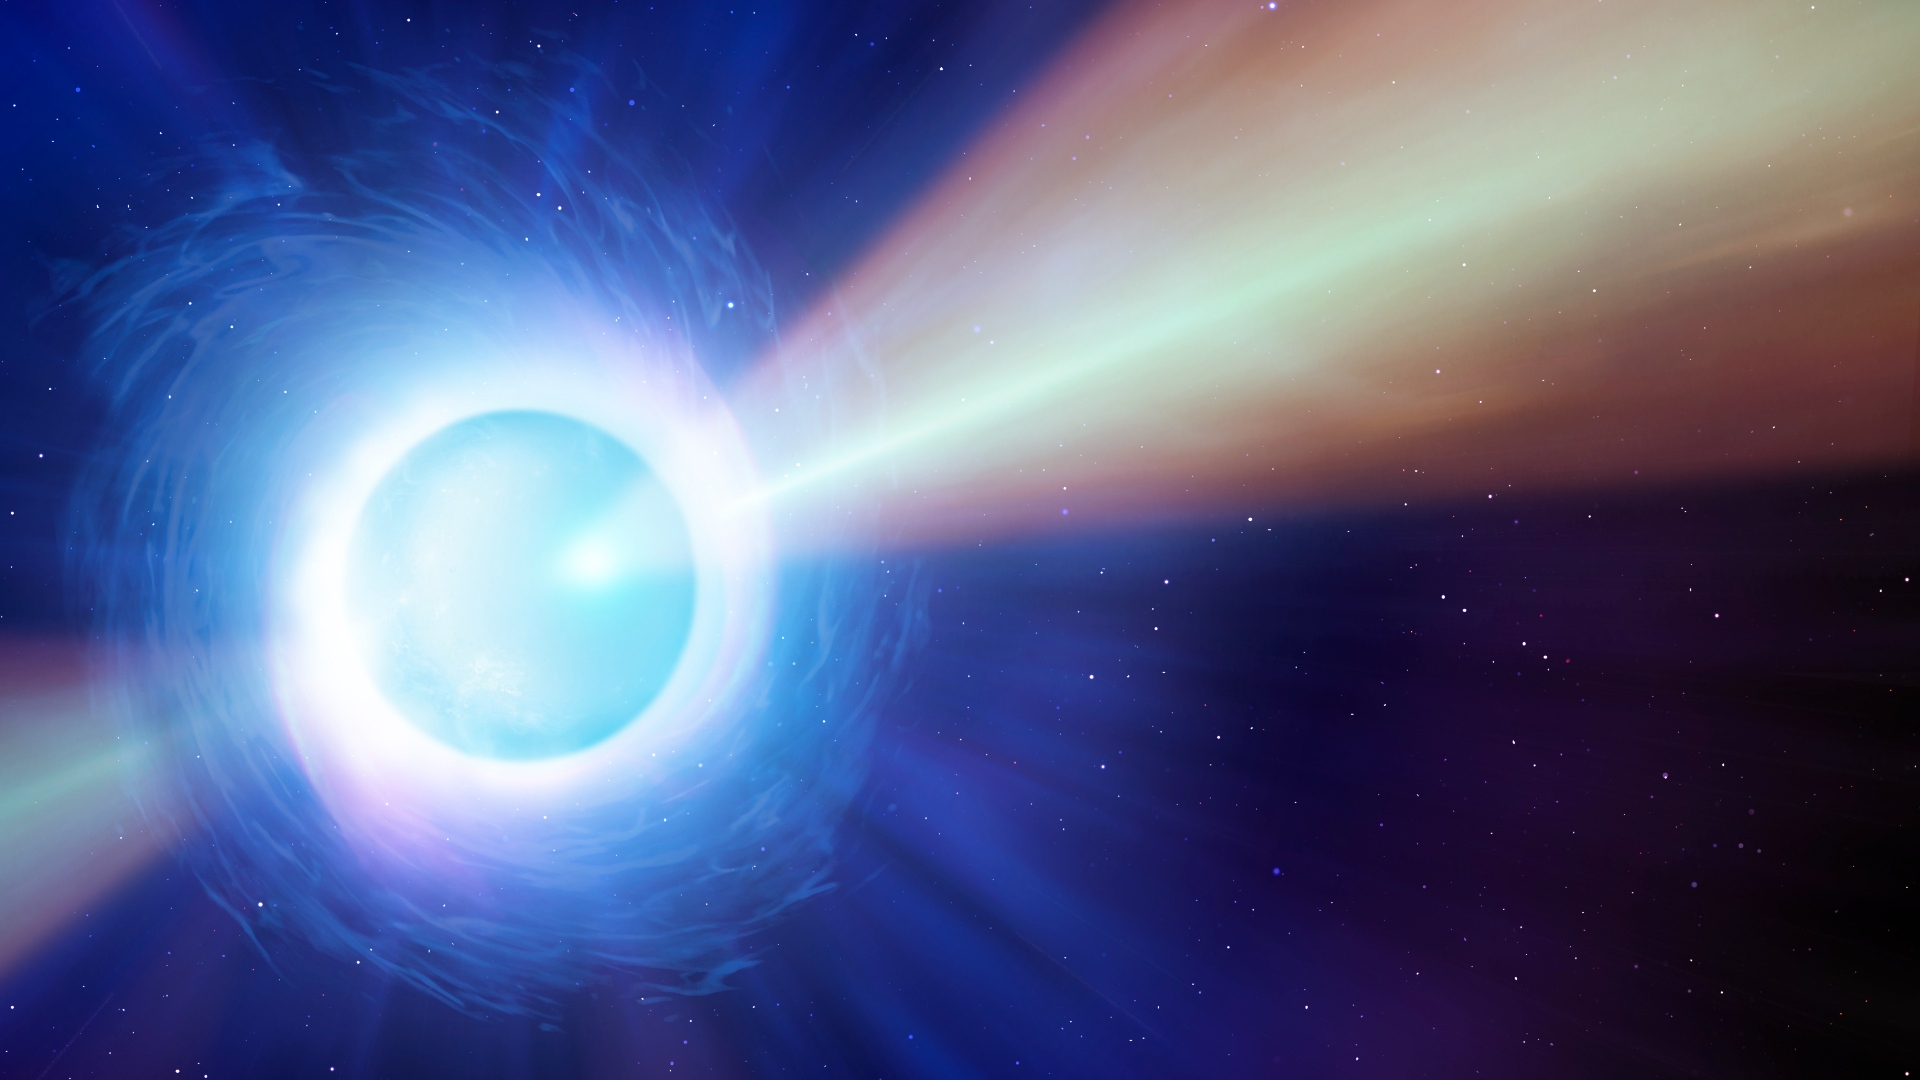

In [ ]:
DATA_PATH = Path("HTRU_2.csv")

FEATURE_NAMES = [
    "profile_mean",
    "profile_stdev",
    "profile_excess_kurtosis",
    "profile_skewness",
    "dm_mean",
    "dm_stdev",
    "dm_excess_kurtosis",
    "dm_skewness",
]

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}. Put HTRU_2.csv beside this notebook."
    )

# The ParserError indicates an inconsistency in the number of fields in some lines.
# Specifically, line 17898 had 13 fields when 9 were expected.
# To handle this, we instruct pandas to use the 'python' engine (which is more robust for malformed CSVs)
# and to skip lines that cause parsing errors using 'on_bad_lines="skip"'.
# Although 'on_bad_lines' is technically deprecated for the default C engine in pandas 2.x,
# it is often still effective with 'engine="python"' for this type of issue.
data = pd.read_csv(DATA_PATH, header=None, names=FEATURE_NAMES + ["class"], engine='python', on_bad_lines='skip')
#data = pd.read_csv(DATA_PATH)
print("Shape:", data.shape)
display(data.head())

Shape: (24944, 9)


,profile_mean,profile_stdev,profile_excess_kurtosis,profile_skewness,dm_mean,dm_stdev,dm_excess_kurtosis,dm_skewness,class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [ ]:
class_counts = data["class"].value_counts().sort_index()
print(class_counts.rename(index={0: "non-pulsar", 1: "pulsar"}))
print(f"Pulsar prevalence: {100 * class_counts[1] / len(data):.2f}%")
print("Missing values:", int(data.isna().sum().sum()))


class
non-pulsar    22964
pulsar         1980
Name: count, dtype: int64
Pulsar prevalence: 7.94%
Missing values: 0


The natural dataset is strongly imbalanced: only about 9% of candidates are pulsars. To keep exact quantum simulation and classroom training fast, we draw a **balanced toy sample of 64 candidates**. Balancing makes accuracy easy to interpret, but it ignores the real prevalence. If we were to perform a production study, we should use the full distribution and emphasize precision, recall, false-positive rate, and probability calibration.


In [ ]:
SAMPLES_PER_CLASS = 32

non_pulsars = data[data["class"] == 0].sample(
    n=SAMPLES_PER_CLASS, random_state=RANDOM_STATE
)
pulsars = data[data["class"] == 1].sample(
    n=SAMPLES_PER_CLASS, random_state=RANDOM_STATE
)

toy_data = (
    pd.concat([non_pulsars, pulsars])
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print(toy_data["class"].value_counts().sort_index())


class
0    32
1    32
Name: count, dtype: int64


### Look at Two Physically Related Feature Pairs

These plots use the raw values only for orientation. Each dot is one candidate; they are not telescope images.


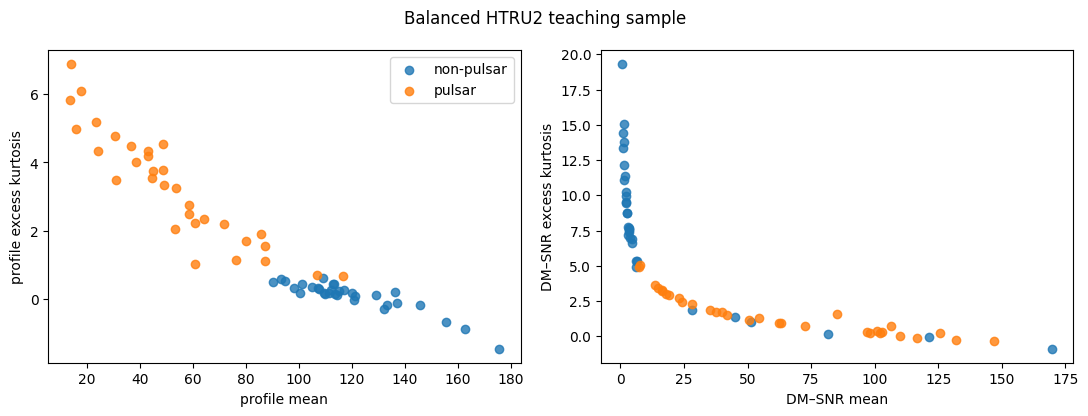

In [ ]:
colors = {0: "tab:blue", 1: "tab:orange"}
labels = {0: "non-pulsar", 1: "pulsar"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for class_value in [0, 1]:
    rows = toy_data[toy_data["class"] == class_value]
    axes[0].scatter(
        rows["profile_mean"],
        rows["profile_excess_kurtosis"],
        alpha=0.8,
        label=labels[class_value],
        color=colors[class_value],
    )
    axes[1].scatter(
        rows["dm_mean"],
        rows["dm_excess_kurtosis"],
        alpha=0.8,
        label=labels[class_value],
        color=colors[class_value],
    )

axes[0].set(xlabel="profile mean", ylabel="profile excess kurtosis")
axes[1].set(xlabel="DM–SNR mean", ylabel="DM–SNR excess kurtosis")
axes[0].legend()
fig.suptitle("Balanced HTRU2 teaching sample")
fig.tight_layout()
plt.show()


## 3. Split and Scale the Data

Qiskit circuits use the feature values as rotation or phase angles, so raw measurements with very different numerical ranges are unsuitable. We map each feature to $[0,\pi/2]$.

The scaler is fitted **only on the training data**, treating the data from the test set as genuinely unseen data.

`NeuralNetworkClassifier` will receive labels $-1$ and $+1$, matching the sign of the final expectation value.


In [ ]:
X = toy_data[FEATURE_NAMES].to_numpy(dtype=float)
y = np.where(toy_data["class"].to_numpy() == 1, 1, -1)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

scaler = MinMaxScaler(feature_range=(0, np.pi / 2))
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)
print("Training labels:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Test labels:    ", dict(zip(*np.unique(y_test, return_counts=True))))


Training set: (48, 8)
Test set:     (16, 8)
Training labels: {np.int64(-1): np.int64(24), np.int64(1): np.int64(24)}
Test labels:     {np.int64(-1): np.int64(8), np.int64(1): np.int64(8)}


## 4. Establish a Classical Baseline

A quantum model should not be judged in isolation. Logistic regression provides a fast, transparent reference using exactly the same training examples, test examples, and scaled features.


In [ ]:
classical_model = LogisticRegression(random_state=RANDOM_STATE)
classical_model.fit(X_train, y_train)

y_pred_classical = classical_model.predict(X_test)
classical_accuracy = accuracy_score(y_test, y_pred_classical)
classical_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_classical)

print(f"Logistic-regression test accuracy: {classical_accuracy:.3f}")


Logistic-regression test accuracy: 0.938


## 5. The Two-Qubit Building Blocks

The QCNN alternates two types of trainable blocks:

1. a **convolution block**, which mixes a pair of qubits; and
2. a **pooling block**, which transfers information from a source qubit to a sink qubit.

Each block below has three trainable angles. It is a deliberately restricted two-qubit unitary, following Qiskit’s QCNN tutorial, so that training remains feasible. A completely general two-qubit unitary would require many more parameters.


In [ ]:
def convolution_block(parameters):
    """A three-parameter unitary acting on two neighbouring qubits."""
    circuit = QuantumCircuit(2, name="U_conv")
    circuit.rz(-np.pi / 2, 1)
    circuit.cx(1, 0)
    circuit.rz(parameters[0], 0)
    circuit.ry(parameters[1], 1)
    circuit.cx(0, 1)
    circuit.ry(parameters[2], 1)
    circuit.cx(1, 0)
    circuit.rz(np.pi / 2, 0)
    return circuit


def pooling_block(parameters):
    """Transfer information from qubit 0 (source) to qubit 1 (sink)."""
    circuit = QuantumCircuit(2, name="U_pool")
    circuit.rz(-np.pi / 2, 1)
    circuit.cx(1, 0)
    circuit.rz(parameters[0], 0)
    circuit.ry(parameters[1], 1)
    circuit.cx(0, 1)
    circuit.ry(parameters[2], 1)
    return circuit


Convolution block


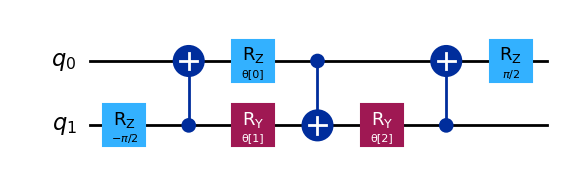

Pooling block: qubit 0 is the source; qubit 1 is retained


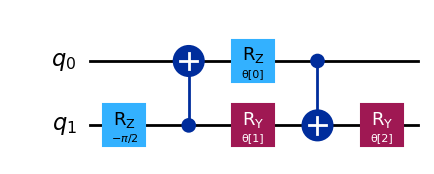

In [ ]:
demo_parameters = ParameterVector("θ", 3)

print("Convolution block")
display(convolution_block(demo_parameters).draw(output="mpl"))
print("Pooling block: qubit 0 is the source; qubit 1 is retained")
pooling_block(demo_parameters).draw(output="mpl")


## 6. Assemble Complete Convolution and Pooling Layers

A convolution layer first applies the block to even neighbour pairs, then to odd neighbour pairs, with circular coupling between the last and first active qubits. A pooling layer pairs source qubits with sink qubits.

This construction uses distinct parameters at different positions, as in the official Qiskit tutorial. Thus the locality and hierarchy are CNN-like, but there is no strict classical-style weight sharing. Sharing one three-parameter vector across all blocks in a layer is a useful extension exercise.

The helper functions wrap each layer as one named instruction. This keeps the final circuit diagram readable.


In [ ]:
def convolution_layer(num_qubits, parameter_prefix):
    layer = QuantumCircuit(num_qubits, name=f"Convolution {parameter_prefix}")
    parameters = ParameterVector(parameter_prefix, length=num_qubits * 3)
    parameter_index = 0

    # Even pairs: (0,1), (2,3), ...
    for q1, q2 in zip(range(0, num_qubits, 2), range(1, num_qubits, 2)):
        block_parameters = parameters[parameter_index : parameter_index + 3]
        layer.compose(convolution_block(block_parameters), [q1, q2], inplace=True)
        parameter_index += 3

    # Odd pairs with circular coupling: (1,2), (3,4), ..., (last,0)
    second_qubits = list(range(2, num_qubits, 2)) + [0]
    for q1, q2 in zip(range(1, num_qubits, 2), second_qubits):
        block_parameters = parameters[parameter_index : parameter_index + 3]
        layer.compose(convolution_block(block_parameters), [q1, q2], inplace=True)
        parameter_index += 3

    wrapped_layer = QuantumCircuit(num_qubits)
    wrapped_layer.append(layer.to_instruction(), range(num_qubits))
    return wrapped_layer


def pooling_layer(source_qubits, sink_qubits, parameter_prefix):
    num_qubits = len(source_qubits) + len(sink_qubits)
    layer = QuantumCircuit(num_qubits, name=f"Pooling {parameter_prefix}")
    parameters = ParameterVector(parameter_prefix, length=3 * len(source_qubits))

    for index, (source, sink) in enumerate(zip(source_qubits, sink_qubits)):
        block_parameters = parameters[3 * index : 3 * index + 3]
        layer.compose(pooling_block(block_parameters), [source, sink], inplace=True)

    wrapped_layer = QuantumCircuit(num_qubits)
    wrapped_layer.append(layer.to_instruction(), range(num_qubits))
    return wrapped_layer


## 7. Encode the Eight Features

`z_feature_map(8)` creates eight input parameters, one per qubit. It applies a Hadamard gate followed by a data-dependent phase rotation. The feature map is not trained: its parameters are replaced by a different row of `X_train` or `X_test` whenever the QNN is evaluated.


Input parameters: 8


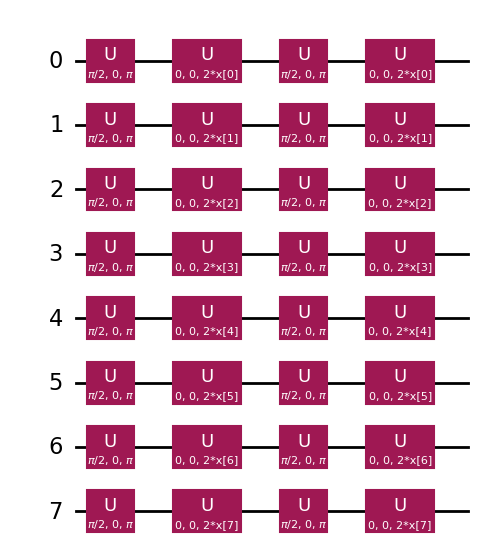

In [ ]:
NUM_QUBITS = len(FEATURE_NAMES)
feature_map = z_feature_map(feature_dimension=NUM_QUBITS)

print("Input parameters:", feature_map.num_parameters)
display(feature_map.decompose().draw(output="mpl", fold=120))


## 8. Build the $8\rightarrow4\rightarrow2\rightarrow1$ QCNN

After each pooling layer, some qubits are still physically present in the circuit but receive no further gates. The active qubits are:

| Stage | Active qubits | Count |
|---|---:|---:|
| encoded input | 0–7 | 8 |
| after pool 1 | 4–7 | 4 |
| after pool 2 | 6–7 | 2 |
| after pool 3 | 7 | 1 |

There are 63 trainable weights in this construction.

Trainable QCNN parameters: 63


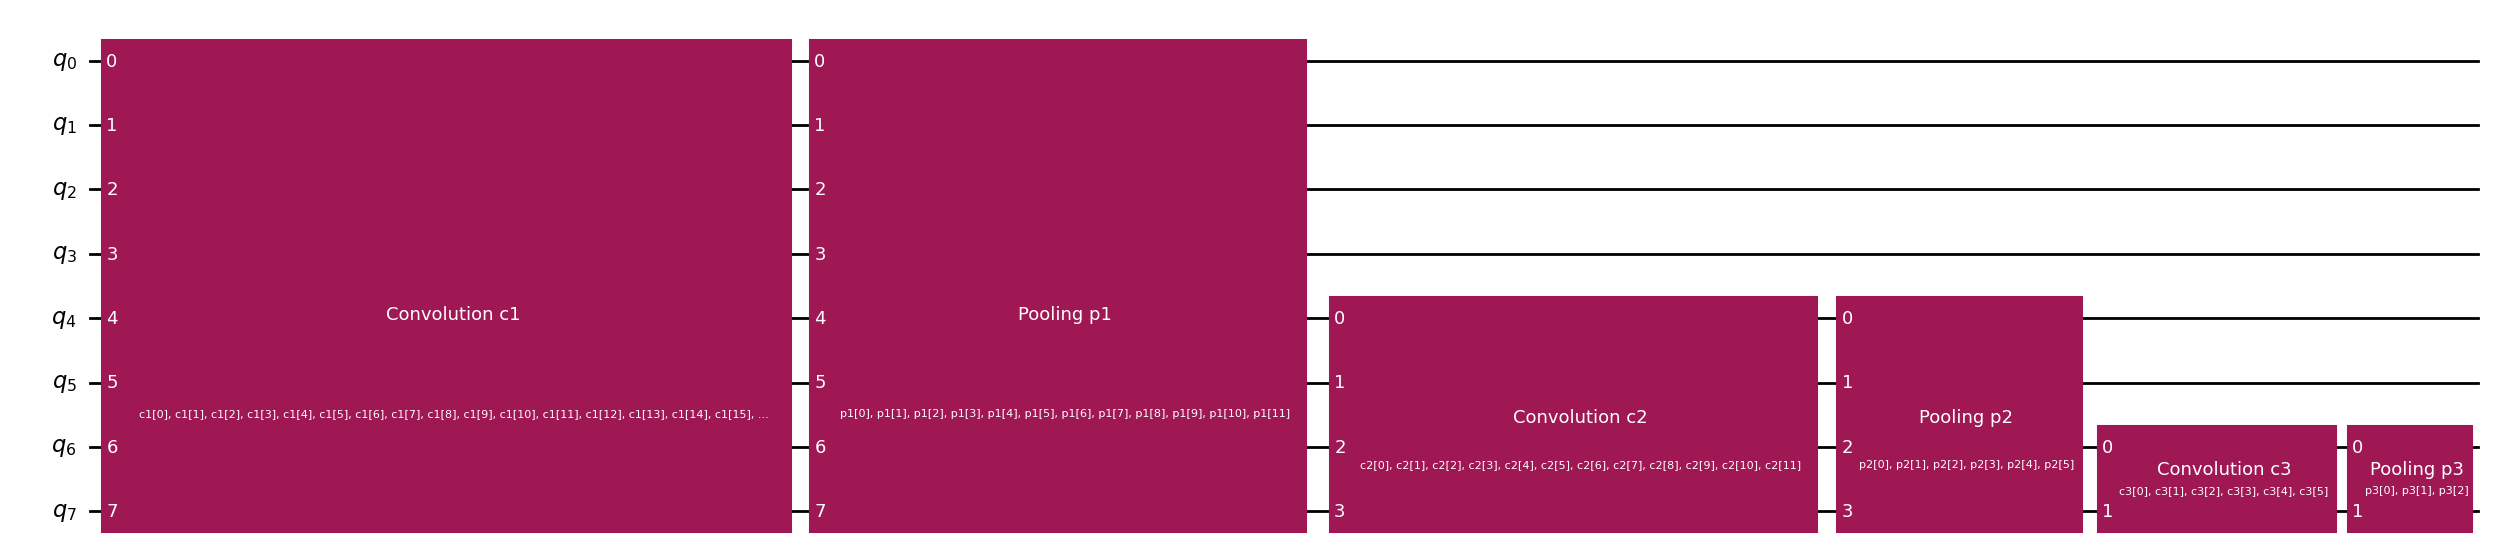

In [ ]:
ansatz = QuantumCircuit(NUM_QUBITS, name="QCNN")

ansatz.compose(convolution_layer(8, "c1"), list(range(8)), inplace=True)
ansatz.compose(pooling_layer([0, 1, 2, 3], [4, 5, 6, 7], "p1"), inplace=True)

ansatz.compose(convolution_layer(4, "c2"), list(range(4, 8)), inplace=True)
ansatz.compose(pooling_layer([0, 1], [2, 3], "p2"), list(range(4, 8)), inplace=True)

ansatz.compose(convolution_layer(2, "c3"), list(range(6, 8)), inplace=True)
ansatz.compose(pooling_layer([0], [1], "p3"), list(range(6, 8)), inplace=True)

print("Trainable QCNN parameters:", ansatz.num_parameters)
display(ansatz.draw(output="mpl", fold=120))


## 9. Turn the Circuit into an `EstimatorQNN`

The complete circuit first loads one data row and then applies the trainable QCNN. We measure the expectation value

$$\langle Z_7\rangle\in[-1,1]$$

on the final active qubit. Negative values favour class $-1$ (non-pulsar); positive values favour class $+1$ (pulsar).

Qiskit writes Pauli strings with the highest-numbered qubit on the left, so `ZIIIIIII` means $Z$ on qubit 7 and identity on qubits 0–6.

`StatevectorEstimator` computes exact expectation values locally. There is no finite-shot sampling noise in this notebook.


In [ ]:
complete_circuit = QuantumCircuit(NUM_QUBITS)
complete_circuit.compose(feature_map, range(NUM_QUBITS), inplace=True)
complete_circuit.compose(ansatz, range(NUM_QUBITS), inplace=True)

# compute the expectation for qubit 7
# string is defined in reverse because of little endian notation
observable = SparsePauliOp.from_list([("Z" + "I" * 7, 1.0)])
estimator = StatevectorEstimator()

qnn = EstimatorQNN(
    circuit=complete_circuit.decompose(),
    observables=observable,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator,
)

print("QNN inputs:", qnn.num_inputs)
print("QNN weights:", qnn.num_weights)
print("QNN output shape:", qnn.output_shape)


QNN inputs: 8
QNN weights: 63
QNN output shape: (1,)


### Inspect the Untrained model

The initial weights are fixed random values. At this point the scores have no learned meaning; this merely checks that data can flow through the circuit.


In [ ]:
weight_rng = np.random.default_rng(RANDOM_STATE)
initial_point = weight_rng.uniform(-np.pi, np.pi, size=qnn.num_weights)

initial_scores = qnn.forward(X_train[:5], initial_point).reshape(-1)
display(pd.DataFrame({
    "true_label": y_train[:5],
    "untrained_<Z7>": initial_scores,
}).round(3))


,true_label,untrained_<Z7>
0,1,-0.173
1,1,0.032
2,-1,-0.080
3,1,-0.137
4,1,-0.039


## 10. Train the QCNN

`NeuralNetworkClassifier` supplies the classical learning loop around the quantum model. At each objective evaluation it:

1. runs the QNN on every training example with the current weights;
2. compares the expectation values with the $-1/+1$ labels using squared error;
3. asks COBYLA for a new set of weights; and
4. repeats until the evaluation budget is exhausted or the optimizer converges.

COBYLA is gradient-free. The quantum circuit supplies model evaluations; the optimizer and data handling remain classical. On a typical laptop, the following exact-simulator training cell should take tens of seconds.


In [ ]:
objective_values = []


def record_objective(weights, objective_value):
    objective_values.append(float(objective_value))


qcnn_classifier = NeuralNetworkClassifier(
    neural_network=qnn,
    loss="squared_error",
    optimizer=COBYLA(maxiter=200),
    initial_point=initial_point,
    callback=record_objective,
)


In [ ]:
start = perf_counter()
qcnn_classifier.fit(X_train, y_train)
training_time = perf_counter() - start

print(f"Training completed in {training_time:.2f} seconds.")
print(f"Objective evaluations: {len(objective_values)}")
print(f"Final objective value: {objective_values[-1]:.4f}")


Training completed in 141.45 seconds.
Objective evaluations: 200
Final objective value: 0.4616


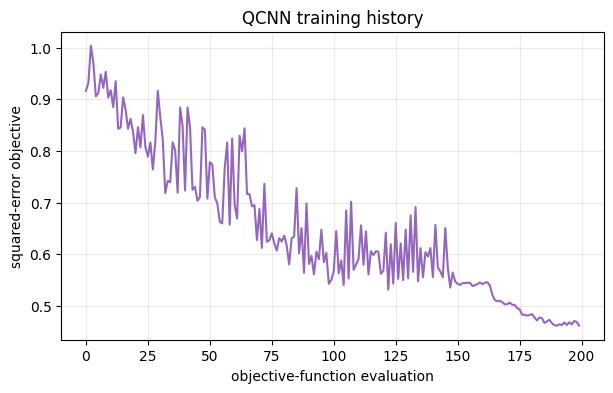

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(objective_values, color="tab:purple")
ax.set(
    xlabel="objective-function evaluation",
    ylabel="squared-error objective",
    title="QCNN training history",
)
ax.grid(alpha=0.25)
plt.show()


A broadly decreasing curve indicates that the optimizer is finding better parameters. It need not decrease at every evaluation because COBYLA explores the parameter space and the objective is non-convex.


## 11. Evaluate on Genuinely Unseen Candidates

The test set was not used to fit the scaler, logistic regression, or QCNN weights.


In [ ]:
y_pred_qcnn = qcnn_classifier.predict(X_test).astype(int).reshape(-1)

qcnn_train_accuracy = qcnn_classifier.score(X_train, y_train)
qcnn_test_accuracy = accuracy_score(y_test, y_pred_qcnn)
qcnn_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_qcnn)

print(f"QCNN training accuracy: {qcnn_train_accuracy:.3f}")
print(f"QCNN test accuracy:     {qcnn_test_accuracy:.3f}")
print()
print(classification_report(
    y_test,
    y_pred_qcnn,
    labels=[-1, 1],
    target_names=["non-pulsar", "pulsar"],
    zero_division=0,
))


QCNN training accuracy: 0.917
QCNN test accuracy:     0.875

              precision    recall  f1-score   support

  non-pulsar       1.00      0.75      0.86         8
      pulsar       0.80      1.00      0.89         8

    accuracy                           0.88        16
   macro avg       0.90      0.88      0.87        16
weighted avg       0.90      0.88      0.87        16



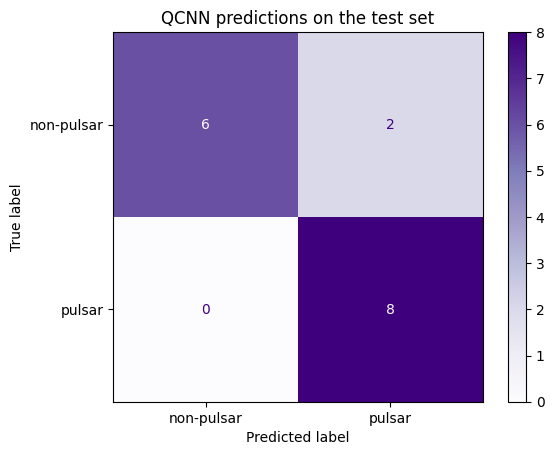

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_qcnn,
    labels=[-1, 1],
    display_labels=["non-pulsar", "pulsar"],
    cmap="Purples",
)
plt.title("QCNN predictions on the test set")
plt.show()


### Inspect the Final Quantum Scores

The classifier thresholds the learned expectation value. Scores far from zero are stronger model decisions; they are **not calibrated probabilities**.


In [ ]:
test_scores = qnn.forward(X_test, qcnn_classifier.weights).reshape(-1)

score_table = pd.DataFrame({
    "true_label": y_test,
    "<Z7>": test_scores,
    "predicted_label": y_pred_qcnn,
})
display(score_table.round(3))


,true_label,<Z7>,predicted_label
0,-1,-0.572,-1
1,1,0.486,1
2,-1,-0.144,-1
3,1,0.380,1
4,-1,-0.280,-1
5,-1,0.168,1
6,-1,-0.101,-1
7,1,0.454,1
8,1,0.383,1
9,1,0.494,1


## 12. Compare the Quantum and Classical Models

With only 16 test examples, one changed prediction moves accuracy by 6.25 percentage points. Treat the following as a reproducible classroom result, not a reliable ranking of model families.


In [ ]:
comparison = pd.DataFrame({
    "model": ["Logistic regression", "QCNN"],
    "test accuracy": [classical_accuracy, qcnn_test_accuracy],
    "balanced accuracy": [classical_balanced_accuracy, qcnn_balanced_accuracy],
    "trainable parameters": [len(FEATURE_NAMES) + 1, qnn.num_weights],
})
display(comparison.round(3))


,model,test accuracy,balanced accuracy,trainable parameters
0,Logistic regression,0.938,0.938,9
1,QCNN,0.875,0.875,63


## 13. Exercises

- Reduce `COBYLA(maxiter=200)` to 50. How do training time and test accuracy change?
- Change the random initial weights. Does the optimizer reach the same solution?
- Replace `z_feature_map(8)` with a custom circuit containing one `ry(x[i], i)` rotation per feature.
- Train on an imbalanced subset that resembles the real class prevalence. Compare accuracy, recall, and precision.
- Replace the exact estimator with a finite-shot estimator and study sampling variability.

### References

- [Qiskit Machine Learning: The Quantum Convolutional Neural Network](https://qiskit-community.github.io/qiskit-machine-learning/tutorials/11_quantum_convolutional_neural_networks.html)
- [UCI Machine Learning Repository: HTRU2](https://archive.ics.uci.edu/dataset/372/htru2), DOI: [10.24432/C5DK6R](https://doi.org/10.24432/C5DK6R), CC BY 4.0
- Cong, Choi & Lukin (2019), [*Quantum convolutional neural networks*](https://doi.org/10.1038/s41567-019-0648-8), *Nature Physics* 15, 1273–1278
- Lyon et al. (2016), *Fifty Years of Pulsar Candidate Selection: From Simple Filters to a New Principled Real-Time Classification Approach*, *MNRAS*

